#Mounting Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:


cd /content/drive/MyDrive/33project/02.자율주행/02.MUNIT

/content/drive/MyDrive/33project/02.자율주행/02.MUNIT


#Installing Dependecies

In [3]:
!pip install --upgrade --no-cache-dir gdown
!pip install tensorboardX
!pip install torchfile

  Attempting uninstall: gdown
    Found existing installation: gdown 5.2.2
    Uninstalling gdown-5.2.2:
      Successfully uninstalled gdown-5.2.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 8.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for torchfile: filename=torchfile-0.1.0-py3-none-any.whl size=5693 sha256=db6c236ed76e8599255796613a5c0f55310cf88389113216b435faba15cb5dbe
  Stored in directory: /root/.cache/pip/wheels/62/68/64/66c57ed3a2bf9a6df8a63e9f28c7c630c5b5c484c4c34e4c3b
Successfully built torchfile


#Importing Libraries

In [4]:
import os
from __future__ import print_function
from utils import get_config, pytorch03_to_pytorch04
from trainer import MUNIT_Trainer, UNIT_Trainer

from torch.autograd import Variable
import torchvision.utils as vutils
import sys
import torch

from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from utils import get_all_data_loaders, prepare_sub_folder, write_html, write_loss, get_config, write_2images, Timer

from torch.autograd import Variable
from trainer import MUNIT_Trainer, UNIT_Trainer
import torch.backends.cudnn as cudnn
from torch import nn
from torch.autograd import Variable

import torch.nn.functional as F
try:
    from itertools import izip as zip
except ImportError: # will be 3.x series
    pass


import tensorboardX
import shutil

#Defining Variables

In [5]:
dataset='edges2handbags'
model='models'

configg='configs/edges2handbags_folder.yaml'
configg_train='configs/demo_edges2handbags_folder.yaml'
input='inputs/edge.jpg'
output_folder='outputs'
checkpoint='models/edges2handbags.pt'
style=''
a2b=1
seed=10
num_style=10
synchronized=False
output_only=False
output_path='.'
trainerr='MUNIT'
output_path='.'
resume=False

#Downloading Dataset

In [6]:
if os.path.exists(dataset) is False:
  print("Downloading Dataset")
  !wget http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/edges2handbags.tar.gz
  !tar -xvzf edges2handbags.tar.gz
else:
  print('Dataset Already Downloaded')

--2026-08-27 07:32:11--  http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/edges2handbags.tar.gz
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.139.28
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.139.28|:80... failed: Connection timed out.
Retrying.

--2026-08-27 07:34:28--  (try: 2)  http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/edges2handbags.tar.gz
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.139.28|:80... failed: Connection timed out.
Retrying.

--2026-08-27 07:36:44--  (try: 3)  http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/edges2handbags.tar.gz
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.139.28|:80... failed: Connection timed out.
Retrying.

--2026-08-27 07:39:00--  (try: 4)  http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/edges2handbags.tar.gz
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.139.28|:

#Downloading PreTrained Model


In [ ]:

if os.path.exists(model) is False:
  !mkdir models
  print("Downloading Pretrained Model")
  %cd models

  !gdown https://drive.google.com/u/0/uc?id=1-nkt5ouwH3_upGhJUWVOnrVmuQq1VyWb&export=download
  %cd ..
else:
  print('Model Already Downloaded')

Model Already Downloaded


#Defining Model

In [ ]:

##################################################################################
# Discriminator
##################################################################################

class MsImageDis(nn.Module):
    # Multi-scale discriminator architecture
    def __init__(self, input_dim, params):
        super(MsImageDis, self).__init__()
        self.n_layer = params['n_layer']
        self.gan_type = params['gan_type']
        self.dim = params['dim']
        self.norm = params['norm']
        self.activ = params['activ']
        self.num_scales = params['num_scales']
        self.pad_type = params['pad_type']
        self.input_dim = input_dim
        self.downsample = nn.AvgPool2d(3, stride=2, padding=[1, 1], count_include_pad=False)
        self.cnns = nn.ModuleList()
        for _ in range(self.num_scales):
            self.cnns.append(self._make_net())

    def _make_net(self):
        dim = self.dim
        cnn_x = []
        cnn_x += [Conv2dBlock(self.input_dim, dim, 4, 2, 1, norm='none', activation=self.activ, pad_type=self.pad_type)]
        for i in range(self.n_layer - 1):
            cnn_x += [Conv2dBlock(dim, dim * 2, 4, 2, 1, norm=self.norm, activation=self.activ, pad_type=self.pad_type)]
            dim *= 2
        cnn_x += [nn.Conv2d(dim, 1, 1, 1, 0)]
        cnn_x = nn.Sequential(*cnn_x)
        return cnn_x

    def forward(self, x):
        outputs = []
        for model in self.cnns:
            outputs.append(model(x))
            x = self.downsample(x)
        return outputs

    def calc_dis_loss(self, input_fake, input_real):
        # calculate the loss to train D
        outs0 = self.forward(input_fake)
        outs1 = self.forward(input_real)
        loss = 0

        for it, (out0, out1) in enumerate(zip(outs0, outs1)):
            if self.gan_type == 'lsgan':
                loss += torch.mean((out0 - 0)**2) + torch.mean((out1 - 1)**2)
            elif self.gan_type == 'nsgan':
                all0 = Variable(torch.zeros_like(out0.data).cuda(), requires_grad=False)
                all1 = Variable(torch.ones_like(out1.data).cuda(), requires_grad=False)
                loss += torch.mean(F.binary_cross_entropy(F.sigmoid(out0), all0) +
                                   F.binary_cross_entropy(F.sigmoid(out1), all1))
            else:
                assert 0, "Unsupported GAN type: {}".format(self.gan_type)
        return loss

    def calc_gen_loss(self, input_fake):
        # calculate the loss to train G
        outs0 = self.forward(input_fake)
        loss = 0
        for it, (out0) in enumerate(outs0):
            if self.gan_type == 'lsgan':
                loss += torch.mean((out0 - 1)**2) # LSGAN
            elif self.gan_type == 'nsgan':
                all1 = Variable(torch.ones_like(out0.data).cuda(), requires_grad=False)
                loss += torch.mean(F.binary_cross_entropy(F.sigmoid(out0), all1))
            else:
                assert 0, "Unsupported GAN type: {}".format(self.gan_type)
        return loss

##################################################################################
# Generator
##################################################################################

class AdaINGen(nn.Module):
    # AdaIN auto-encoder architecture
    def __init__(self, input_dim, params):
        super(AdaINGen, self).__init__()
        dim = params['dim']
        style_dim = params['style_dim']
        n_downsample = params['n_downsample']
        n_res = params['n_res']
        activ = params['activ']
        pad_type = params['pad_type']
        mlp_dim = params['mlp_dim']

        # style encoder
        self.enc_style = StyleEncoder(4, input_dim, dim, style_dim, norm='none', activ=activ, pad_type=pad_type)

        # content encoder
        self.enc_content = ContentEncoder(n_downsample, n_res, input_dim, dim, 'in', activ, pad_type=pad_type)
        self.dec = Decoder(n_downsample, n_res, self.enc_content.output_dim, input_dim, res_norm='adain', activ=activ, pad_type=pad_type)

        # MLP to generate AdaIN parameters
        self.mlp = MLP(style_dim, self.get_num_adain_params(self.dec), mlp_dim, 3, norm='none', activ=activ)

    def forward(self, images):
        # reconstruct an image
        content, style_fake = self.encode(images)
        images_recon = self.decode(content, style_fake)
        return images_recon

    def encode(self, images):
        # encode an image to its content and style codes
        style_fake = self.enc_style(images)
        content = self.enc_content(images)
        return content, style_fake

    def decode(self, content, style):
        # decode content and style codes to an image
        adain_params = self.mlp(style)
        self.assign_adain_params(adain_params, self.dec)
        images = self.dec(content)
        return images

    def assign_adain_params(self, adain_params, model):
        # assign the adain_params to the AdaIN layers in model
        for m in model.modules():
            if m.__class__.__name__ == "AdaptiveInstanceNorm2d":
                mean = adain_params[:, :m.num_features]
                std = adain_params[:, m.num_features:2*m.num_features]
                m.bias = mean.contiguous().view(-1)
                m.weight = std.contiguous().view(-1)
                if adain_params.size(1) > 2*m.num_features:
                    adain_params = adain_params[:, 2*m.num_features:]

    def get_num_adain_params(self, model):
        # return the number of AdaIN parameters needed by the model
        num_adain_params = 0
        for m in model.modules():
            if m.__class__.__name__ == "AdaptiveInstanceNorm2d":
                num_adain_params += 2*m.num_features
        return num_adain_params


class VAEGen(nn.Module):
    # VAE architecture
    def __init__(self, input_dim, params):
        super(VAEGen, self).__init__()
        dim = params['dim']
        n_downsample = params['n_downsample']
        n_res = params['n_res']
        activ = params['activ']
        pad_type = params['pad_type']

        # content encoder
        self.enc = ContentEncoder(n_downsample, n_res, input_dim, dim, 'in', activ, pad_type=pad_type)
        self.dec = Decoder(n_downsample, n_res, self.enc.output_dim, input_dim, res_norm='in', activ=activ, pad_type=pad_type)

    def forward(self, images):
        # This is a reduced VAE implementation where we assume the outputs are multivariate Gaussian distribution with mean = hiddens and std_dev = all ones.
        hiddens = self.encode(images)
        if self.training == True:
            noise = Variable(torch.randn(hiddens.size()).cuda(hiddens.data.get_device()))
            images_recon = self.decode(hiddens + noise)
        else:
            images_recon = self.decode(hiddens)
        return images_recon, hiddens

    def encode(self, images):
        hiddens = self.enc(images)
        noise = Variable(torch.randn(hiddens.size()).cuda(hiddens.data.get_device()))
        return hiddens, noise

    def decode(self, hiddens):
        images = self.dec(hiddens)
        return images



#Training Script

In [ ]:
cudnn.benchmark = True

# Load experiment setting
config = get_config(configg_train)
max_iter = config['max_iter']
display_size = config['display_size']
config['vgg_model_path'] = output_path

# Setup model and data loader
if trainerr == 'MUNIT':
    trainer = MUNIT_Trainer(config)
elif trainerr == 'UNIT':
    trainer = UNIT_Trainer(config)
else:
    sys.exit("Only support MUNIT|UNIT")
trainer.cuda()
train_loader_a, train_loader_b, test_loader_a, test_loader_b = get_all_data_loaders(config)
train_display_images_a = torch.stack([train_loader_a.dataset[i] for i in range(display_size)]).cuda()
train_display_images_b = torch.stack([train_loader_b.dataset[i] for i in range(display_size)]).cuda()
test_display_images_a = torch.stack([test_loader_a.dataset[i] for i in range(display_size)]).cuda()
test_display_images_b = torch.stack([test_loader_b.dataset[i] for i in range(display_size)]).cuda()

# Setup logger and output folders
model_name = os.path.splitext(os.path.basename(configg_train))[0]
train_writer = tensorboardX.SummaryWriter(os.path.join(output_path + "/logs", model_name))
output_directory = os.path.join(output_path + "/outputs", model_name)
checkpoint_directory, image_directory = prepare_sub_folder(output_directory)
shutil.copy(configg_train, os.path.join(output_directory, 'config.yaml')) # copy config file to output folder

# Start training
iterations = trainer.resume(checkpoint_directory, hyperparameters=config) if resume else 0
while True:
    for it, (images_a, images_b) in enumerate(zip(train_loader_a, train_loader_b)):
        trainer.update_learning_rate()
        images_a, images_b = images_a.cuda().detach(), images_b.cuda().detach()

        with Timer("Elapsed time in update: %f"):
            # Main training code
            trainer.dis_update(images_a, images_b, config)
            trainer.gen_update(images_a, images_b, config)
            torch.cuda.synchronize()

        # Dump training stats in log file
        if (iterations + 1) % config['log_iter'] == 0:
            print("Iteration: %08d/%08d" % (iterations + 1, max_iter))
            write_loss(iterations, trainer, train_writer)

        # Write images
        if (iterations + 1) % config['image_save_iter'] == 0:
            with torch.no_grad():
                test_image_outputs = trainer.sample(test_display_images_a, test_display_images_b)
                train_image_outputs = trainer.sample(train_display_images_a, train_display_images_b)
            write_2images(test_image_outputs, display_size, image_directory, 'test_%08d' % (iterations + 1))
            write_2images(train_image_outputs, display_size, image_directory, 'train_%08d' % (iterations + 1))
            # HTML
            write_html(output_directory + "/index.html", iterations + 1, config['image_save_iter'], 'images')

        if (iterations + 1) % config['image_display_iter'] == 0:
            with torch.no_grad():
                image_outputs = trainer.sample(train_display_images_a, train_display_images_b)
            write_2images(image_outputs, display_size, image_directory, 'train_current')

        # Save network weights
        if (iterations + 1) % config['snapshot_save_iter'] == 0:
            trainer.save(checkpoint_directory, iterations)

        iterations += 1
        if iterations >= max_iter:
            sys.exit('Finish training')









/usr/local/lib/python3.8/dist-packages/torch/utils/data/dataloader.py:554: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
/usr/local/lib/python3.8/dist-packages/torch/optim/lr_scheduler.py:138: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `

Elapsed time in update: 4.820436
Iteration: 00000001/01000000
Elapsed time in update: 0.697993
Iteration: 00000002/01000000
Elapsed time in update: 0.713565
Iteration: 00000003/01000000
Elapsed time in update: 0.360173


KeyboardInterrupt: ignored

#Inference Script

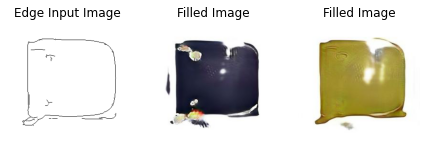

In [ ]:

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# Load experiment setting
config = get_config(configg)
num_style = 1 if style != '' else num_style


# Setup model and data loader
config['vgg_model_path'] = output_path
if trainerr == 'MUNIT':
    style_dim = config['gen']['style_dim']

    trainer = MUNIT_Trainer(config)

elif trainerr == 'UNIT':
    trainer = UNIT_Trainer(config)
else:
    sys.exit("Only support MUNIT|UNIT")

try:
    state_dict = torch.load(checkpoint)

    trainer.gen_a.load_state_dict(state_dict['a'])
    trainer.gen_b.load_state_dict(state_dict['b'])
except:
    state_dict = pytorch03_to_pytorch04(torch.load(checkpoint), trainerr)
    trainer.gen_a.load_state_dict(state_dict['a'])
    trainer.gen_b.load_state_dict(state_dict['b'])

trainer.cuda()
trainer.eval()
encode = trainer.gen_a.encode if a2b else trainer.gen_b.encode # encode function
style_encode = trainer.gen_b.encode if a2b else trainer.gen_a.encode # encode function
decode = trainer.gen_b.decode if a2b else trainer.gen_a.decode # decode function

if 'new_size' in config:
    new_size = config['new_size']
else:
    if a2b==1:
        new_size = config['new_size_a']
    else:
        new_size = config['new_size_b']

with torch.no_grad():
    transform = transforms.Compose([transforms.Resize(new_size),
                                    transforms.ToTensor(),
                                    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
    image = Variable(transform(Image.open(input).convert('RGB')).unsqueeze(0).cuda())
    style_image = Variable(transform(Image.open(style).convert('RGB')).unsqueeze(0).cuda()) if style != '' else None

    # Start testing
    content, _ = encode(image)

    if trainerr == 'MUNIT':
        style_rand = Variable(torch.randn(num_style, style_dim, 1, 1).cuda())
        if style != '':
            _, style = style_encode(style_image)
        else:
            style = style_rand
        for j in range(num_style):
            s = style[j].unsqueeze(0)
            outputs = decode(content, s)
            outputs = (outputs + 1) / 2.
            path = os.path.join(output_folder, 'output{:03d}.jpg'.format(j))
            vutils.save_image(outputs.data, path, padding=0, normalize=True)
    elif trainerr == 'UNIT':
        outputs = decode(content)
        outputs = (outputs + 1) / 2.
        path = os.path.join(output_folder, 'output.jpg')
        vutils.save_image(outputs.data, path, padding=0, normalize=True)
    else:
        pass

    if not output_only:
        # also save input images
        vutils.save_image(image.data, os.path.join(output_folder, 'input.jpg'), padding=0, normalize=True)

files = [f for f in os.listdir(output_folder) if os.path.isfile(os.path.join(output_folder, f))]

# filter only image files
images = [f for f in files if f.endswith(".jpg") or f.endswith(".png")]

# retrieve the first three images
display_images = images[:3]

fig = plt.figure(figsize=(10, 5))

# display the images
for i, image in enumerate(display_images):

    img = plt.imread(os.path.join(output_folder, image))
    if i==0:
      img=plt.imread(input)
    plt.subplot(1, 4, i+1)
    plt.imshow(img,cmap='gray')
    if i==0:
      plt.title('Edge Input Image')
    else:
      plt.title('Filled Image')
    plt.axis("off")

plt.show()
